# 🔲 Convolution Benchmark: MPS vs CPU

Convolutions are inherently GPU-friendly and less optimised by Apple's AMX coprocessors,
making them a workload where MPS can shine even on smaller Apple Silicon chips.

In [ ]:
import torch
from metalcheck import device_info, is_mps_available
from metalcheck.utils import benchmark_conv2d

## 1. Device & System Information

In [2]:
info = device_info()
for k, v in info.items():
    label = k.replace("_", " ").title()
    print(f"{label:<20s}: {v}")

Pytorch Version     : 2.10.0
Python Version      : 3.12.13
Platform            : macOS-26.3.2-arm64-arm-64bit
Architecture        : arm64
Mps Built           : True
Mps Available       : True
Device              : mps


## 2. Conv2d Benchmark

Benchmark standalone `Conv2d` at various spatial sizes, kernel sizes, and channel counts.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

spatial_sizes = [64, 128, 256, 512]
kernel_sizes = [3, 5, 7]
channels = 64  # fixed for the main comparison
results = []

for spatial in spatial_sizes:
    for ks in kernel_sizes:
        for dev_name, dev in [("MPS", torch.device("mps")), ("CPU", torch.device("cpu"))]:
            if dev_name == "MPS" and not is_mps_available():
                continue
            print(f"  spatial={spatial} kernel={ks} | {dev_name} ...", end=" ", flush=True)
            r = benchmark_conv2d(
                spatial_size=spatial,
                in_channels=channels,
                out_channels=channels,
                kernel_size=ks,
                batch_size=1,
                device=dev,
                iterations=10,
            )
            results.append({
                "Spatial": f"{spatial}x{spatial}",
                "Kernel": ks,
                "Device": dev_name,
                "Time (ms)": r["mean_time_s"] * 1000,
            })
            print(f"{r['mean_time_s']*1000:.2f} ms")

df = pd.DataFrame(results)
print("\nConv2d benchmark complete!")

  spatial=64 kernel=3 | MPS ... 1.15 ms
  spatial=64 kernel=3 | CPU ... 0.41 ms
  spatial=64 kernel=5 | MPS ... 2.13 ms
  spatial=64 kernel=5 | CPU ... 2.38 ms
  spatial=64 kernel=7 | MPS ... 3.13 ms
  spatial=64 kernel=7 | CPU ... 4.89 ms
  spatial=128 kernel=3 | MPS ... 2.03 ms
  spatial=128 kernel=3 | CPU ... 3.37 ms
  spatial=128 kernel=5 | MPS ... 3.68 ms
  spatial=128 kernel=5 | CPU ... 10.50 ms
  spatial=128 kernel=7 | MPS ... 5.48 ms
  spatial=128 kernel=7 | CPU ... 21.04 ms
  spatial=256 kernel=3 | MPS ... 3.35 ms
  spatial=256 kernel=3 | CPU ... 19.67 ms
  spatial=256 kernel=5 | MPS ... 9.72 ms
  spatial=256 kernel=5 | CPU ... 46.79 ms
  spatial=256 kernel=7 | MPS ... 18.79 ms
  spatial=256 kernel=7 | CPU ... 93.18 ms
  spatial=512 kernel=3 | MPS ... 9.60 ms
  spatial=512 kernel=3 | CPU ... 74.80 ms
  spatial=512 kernel=5 | MPS ... 38.40 ms
  spatial=512 kernel=5 | CPU ... 218.86 ms
  spatial=512 kernel=7 | MPS ... 80.81 ms
  spatial=512 kernel=7 | CPU ... 912.45 ms

Conv2d b

## 3. Visualization

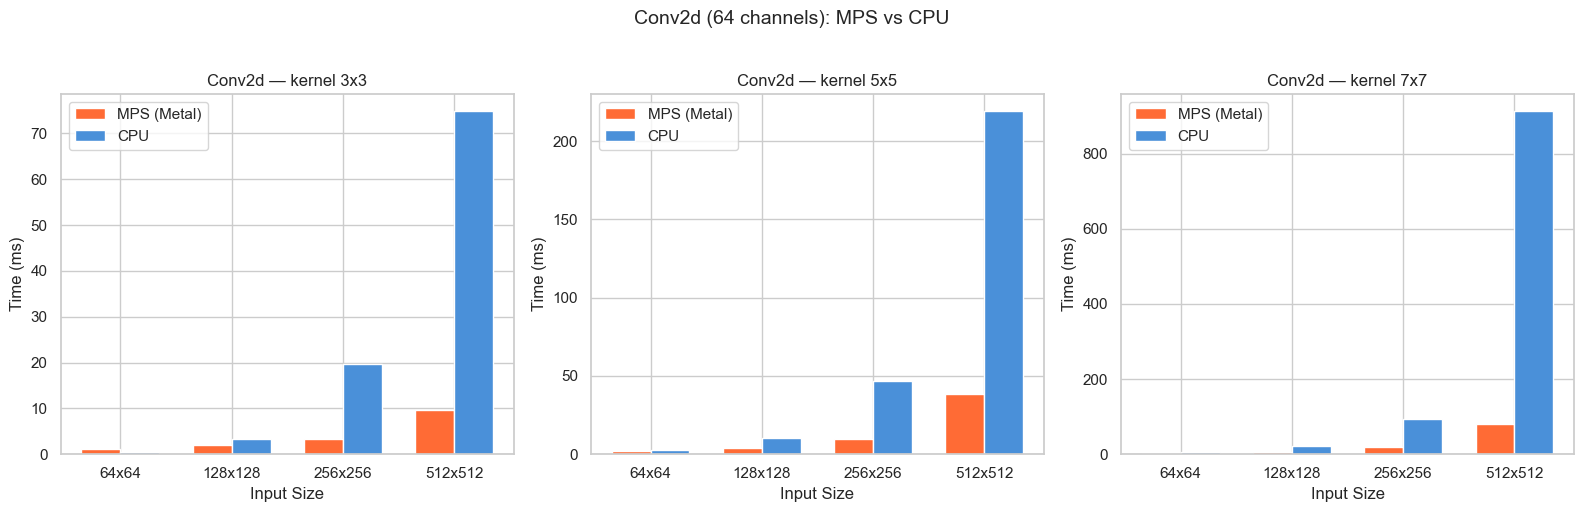

In [4]:
fig, axes = plt.subplots(1, len(kernel_sizes), figsize=(16, 5), sharey=False)

for ax, ks in zip(axes, kernel_sizes):
    df_ks = df[df["Kernel"] == ks]
    spatial_labels = [f"{s}x{s}" for s in spatial_sizes]
    x = range(len(spatial_sizes))
    width = 0.35

    mps_vals = df_ks[df_ks["Device"] == "MPS"]["Time (ms)"].tolist()
    cpu_vals = df_ks[df_ks["Device"] == "CPU"]["Time (ms)"].tolist()

    if mps_vals:
        ax.bar([i - width / 2 for i in x], mps_vals, width, label="MPS (Metal)", color="#FF6B35")
    ax.bar([i + width / 2 for i in x], cpu_vals, width, label="CPU", color="#4A90D9")

    ax.set_xlabel("Input Size")
    ax.set_ylabel("Time (ms)")
    ax.set_title(f"Conv2d — kernel {ks}x{ks}")
    ax.set_xticks(list(x))
    ax.set_xticklabels(spatial_labels)
    ax.legend()

plt.suptitle(f"Conv2d ({channels} channels): MPS vs CPU", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Channel Scaling

How does increasing the number of channels affect MPS vs CPU at a fixed spatial size?

In [5]:
channel_counts = [32, 64, 128, 256]
fixed_spatial = 128
fixed_kernel = 3
channel_results = []

for ch in channel_counts:
    for dev_name, dev in [("MPS", torch.device("mps")), ("CPU", torch.device("cpu"))]:
        if dev_name == "MPS" and not is_mps_available():
            continue
        print(f"  channels={ch} | {dev_name} ...", end=" ", flush=True)
        r = benchmark_conv2d(
            spatial_size=fixed_spatial,
            in_channels=ch,
            out_channels=ch,
            kernel_size=fixed_kernel,
            batch_size=1,
            device=dev,
            iterations=10,
        )
        channel_results.append({
            "Channels": ch,
            "Device": dev_name,
            "Time (ms)": r["mean_time_s"] * 1000,
        })
        print(f"{r['mean_time_s']*1000:.2f} ms")

df_ch = pd.DataFrame(channel_results)
print("\nChannel scaling benchmark complete!")

  channels=32 | MPS ... 1.08 ms
  channels=32 | CPU ... 1.35 ms
  channels=64 | MPS ... 2.91 ms
  channels=64 | CPU ... 3.54 ms
  channels=128 | MPS ... 5.62 ms
  channels=128 | CPU ... 12.93 ms
  channels=256 | MPS ... 9.31 ms
  channels=256 | CPU ... 43.22 ms

Channel scaling benchmark complete!


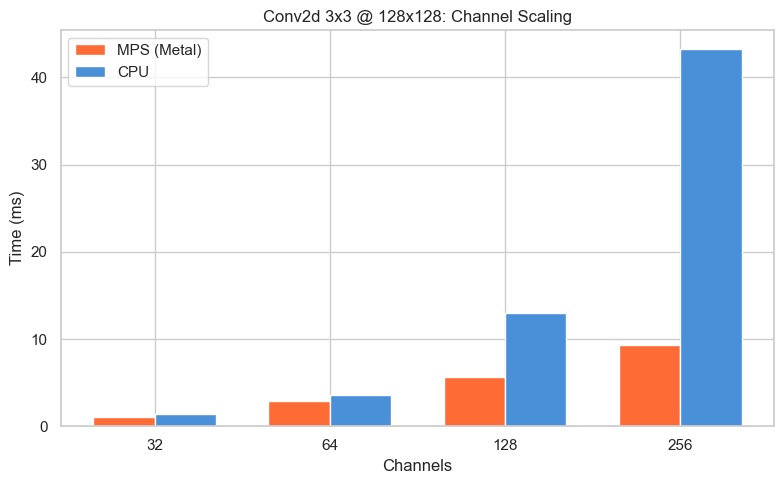

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

x = range(len(channel_counts))
width = 0.35

mps_vals = df_ch[df_ch["Device"] == "MPS"]["Time (ms)"].tolist()
cpu_vals = df_ch[df_ch["Device"] == "CPU"]["Time (ms)"].tolist()

if mps_vals:
    ax.bar([i - width / 2 for i in x], mps_vals, width, label="MPS (Metal)", color="#FF6B35")
ax.bar([i + width / 2 for i in x], cpu_vals, width, label="CPU", color="#4A90D9")

ax.set_xlabel("Channels")
ax.set_ylabel("Time (ms)")
ax.set_title(f"Conv2d {fixed_kernel}x{fixed_kernel} @ {fixed_spatial}x{fixed_spatial}: Channel Scaling")
ax.set_xticks(list(x))
ax.set_xticklabels([str(c) for c in channel_counts])
ax.legend()

plt.tight_layout()
plt.show()

## 5. Speedup Summary

In [7]:
if is_mps_available():
    rows = []
    for spatial in spatial_sizes:
        for ks in kernel_sizes:
            label = f"{spatial}x{spatial}"
            mps_t = df[(df["Spatial"] == label) & (df["Kernel"] == ks) & (df["Device"] == "MPS")]["Time (ms)"].values[0]
            cpu_t = df[(df["Spatial"] == label) & (df["Kernel"] == ks) & (df["Device"] == "CPU")]["Time (ms)"].values[0]
            rows.append({"Input": label, "Kernel": f"{ks}x{ks}", "MPS (ms)": f"{mps_t:.2f}", "CPU (ms)": f"{cpu_t:.2f}", "Speedup": f"{cpu_t / mps_t:.1f}x"})
    display(pd.DataFrame(rows))
else:
    print("MPS not available — ran CPU only.")

,Input,Kernel,MPS (ms),CPU (ms),Speedup
0,64x64,3x3,1.15,0.41,0.4x
1,64x64,5x5,2.13,2.38,1.1x
2,64x64,7x7,3.13,4.89,1.6x
3,128x128,3x3,2.03,3.37,1.7x
4,128x128,5x5,3.68,10.50,2.9x
5,128x128,7x7,5.48,21.04,3.8x
6,256x256,3x3,3.35,19.67,5.9x
7,256x256,5x5,9.72,46.79,4.8x
8,256x256,7x7,18.79,93.18,5.0x
9,512x512,3x3,9.60,74.80,7.8x
